In [1286]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

In [1287]:
sns.set_theme(context='notebook',style='darkgrid',palette='Set1')

In [1288]:
df= pd.read_csv(r'dataset\realKnownCause\realKnownCause\nyc_taxi.csv')

In [1289]:
df.head()

,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


In [1290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  10320 non-null  object
 1   value      10320 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 161.4+ KB


In [1291]:
df.set_index('timestamp', inplace= True)

In [1292]:
df.index= pd.to_datetime(df.index, format='mixed')

In [1293]:
df.sort_index(inplace=True)

In [1294]:
df.isnull().sum()

value    0
dtype: int64

In [1295]:
df.value.resample('ME').mean()

timestamp
2014-07-31    14994.084677
2014-08-31    14580.438844
2014-09-30    15623.374306
2014-10-31    16086.851478
2014-11-30    15492.125000
2014-12-31    14813.428763
2015-01-31    14399.790995
Freq: ME, Name: value, dtype: float64

In [1296]:
hourly= df.resample('h').mean()
daily= df.resample('D').mean()
monthly= df.resample('ME').mean()

In [1297]:
hourly= hourly.asfreq('h')
daily= daily.asfreq('D')
monthly= monthly.asfreq('ME')

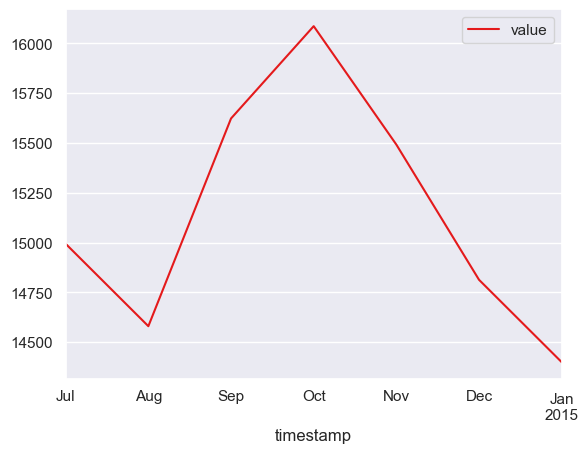

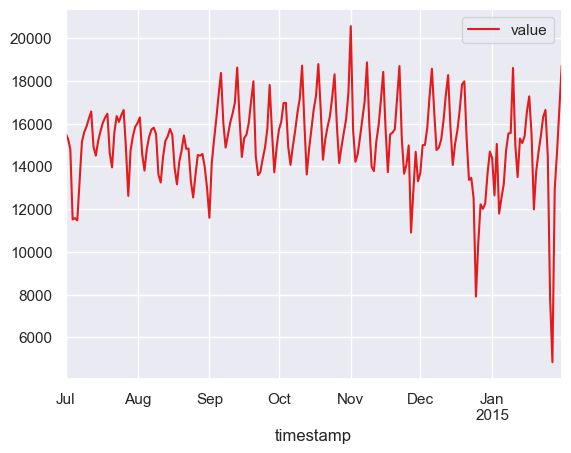

In [1298]:
monthly.plot(label='values by monty')
daily.plot(label= 'values daily')


plt.show()

In [1299]:
def feature_engineering(data, frequency=str):
  data['day']= data.index.day
  data['month']= data.index.month
  data['year']= data.index.year
  data['dayofyear']= data.index.dayofyear

   

  if frequency== 'daily':
    lags= [1,2,3,7,14,30]
    window= [3,7,14,30]
  elif frequency== 'hourly':
    lags= [1,2,3,5,12,24]
    window=[3,6,12,24]
  elif frequency == 'monthly':
    lags = [1,2,3,6,12]
    window= [3,6,12]
  else:
    print('Enter either daily,hourly or monthly')

  # Adding time stamped lags
  for lag in lags:
    data[f'lag_{lag}']= data['value'].shift(lag)

  # Adding rolling window 
  for i in window:
    data[f'{i}_window_mean']= data['value'].rolling(window=i).mean()
    data[f'{i}_window_std']= data['value'].rolling(window=i).std()
    data[f'{i}_window_max']= data['value'].rolling(window=i).max()
  return data

In [1300]:
hourly= feature_engineering(hourly,'hourly')

In [1301]:
hourly.dropna(inplace=True)

In [1302]:
hourly.head()

,value,day,month,year,dayofyear,lag_1,lag_2,lag_3,lag_5,lag_12,...,3_window_max,6_window_mean,6_window_std,6_window_max,12_window_mean,12_window_std,12_window_max,24_window_mean,24_window_std,24_window_max
timestamp,,,,,,,,,,,,,,,,,,,,,
2014-07-02 00:00:00,11657.5,2,7,2014,183,18107.5,22525.5,23920.0,25865.5,18897.0,...,22525.5,20618.416667,5093.220164,25865.5,20068.833333,4091.858387,25865.5,15631.479167,7474.667995,25865.5
2014-07-02 01:00:00,6744.0,2,7,2014,183,11657.5,18107.5,22525.5,21634.5,18818.5,...,18107.5,17431.500000,6837.154167,23920.0,19062.625000,5624.740342,25865.5,15686.104167,7401.327475,25865.5
2014-07-02 02:00:00,4227.0,2,7,2014,183,6744.0,11657.5,18107.5,23920.0,20068.5,...,11657.5,14530.250000,8245.283347,23920.0,17742.500000,7046.507630,25865.5,15722.791667,7339.425540,25865.5
2014-07-02 03:00:00,2764.0,2,7,2014,183,4227.0,6744.0,11657.5,22525.5,18962.0,...,6744.0,11004.250000,7944.868349,22525.5,16392.666667,8241.743247,25865.5,15745.604167,7296.344302,25865.5
2014-07-02 04:00:00,2527.5,2,7,2014,183,2764.0,4227.0,6744.0,18107.5,15620.5,...,4227.0,7671.250000,6132.983293,18107.5,15301.583333,9167.882180,25865.5,15759.687500,7269.316939,25865.5


In [1303]:
x= hourly.copy()

In [1304]:
scale= StandardScaler()

In [1305]:
scale.fit(x)

StandardScaler()

In [1306]:
x= scale.transform(x)

In [1307]:
pca= PCA(n_components=2)
x_pca= pca.fit_transform(x)

In [1308]:
hourly['x'], hourly['y']= x_pca[:,0], x_pca[:,1]

In [1309]:
model= IsolationForest(
        n_estimators=400,
        max_samples=500,
        n_jobs=-1,
        random_state=42,
        contamination='auto',
        max_features=1
)

In [1310]:
model.fit(x)

IsolationForest(max_features=1, max_samples=500, n_estimators=400, n_jobs=-1,
                random_state=42)

In [1311]:
predictions= model.predict(x)

In [1312]:
score= model.decision_function(x)

In [1313]:
hourly['anomaly']= predictions
hourly['score']= score

In [1314]:
hourly['anomaly']= hourly['anomaly'].apply(lambda x : 'Anomaly' if x == -1 else 'Normal')

In [1315]:
hourly['anomaly'].value_counts()

anomaly
Normal     4124
Anomaly    1012
Name: count, dtype: int64

In [1316]:
hourly= hourly[['value','day','month','year','anomaly','score','x','y']]

In [1317]:
hourly.sample(5)

,value,day,month,year,anomaly,score,x,y
timestamp,,,,,,,,
2014-08-15 13:00:00,16648.0,15,8,2014,Normal,0.040526,0.181280,-1.596327
2015-01-02 05:00:00,2220.5,2,1,2015,Anomaly,-0.056022,-6.949599,-2.797312
2015-01-03 03:00:00,9579.5,3,1,2015,Normal,0.012817,-1.166592,-0.737208
2014-07-08 12:00:00,18079.0,8,7,2014,Normal,0.039547,0.094444,-1.766740
2014-12-28 23:00:00,10850.0,28,12,2014,Anomaly,-0.009756,-1.580639,-3.451706


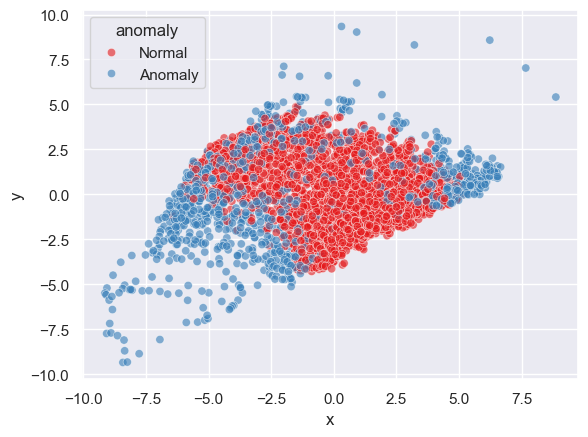

In [1318]:
sns.scatterplot(data=hourly, x='x', y='y', hue='anomaly', alpha=0.6)

plt.show()

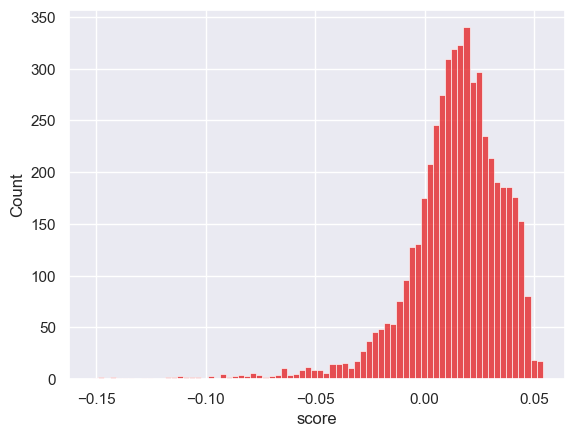

In [1319]:
sns.histplot(data=hourly, x='score')

plt.show()

In [1320]:
hourly.head()

,value,day,month,year,anomaly,score,x,y
timestamp,,,,,,,,
2014-07-02 00:00:00,11657.5,2,7,2014,Normal,0.003232,2.692958,2.186112
2014-07-02 01:00:00,6744.0,2,7,2014,Normal,0.009327,0.699681,3.050823
2014-07-02 02:00:00,4227.0,2,7,2014,Anomaly,-0.001201,-1.041829,3.672279
2014-07-02 03:00:00,2764.0,2,7,2014,Anomaly,-0.000597,-2.591153,3.714661
2014-07-02 04:00:00,2527.5,2,7,2014,Normal,0.007357,-3.797885,3.215069


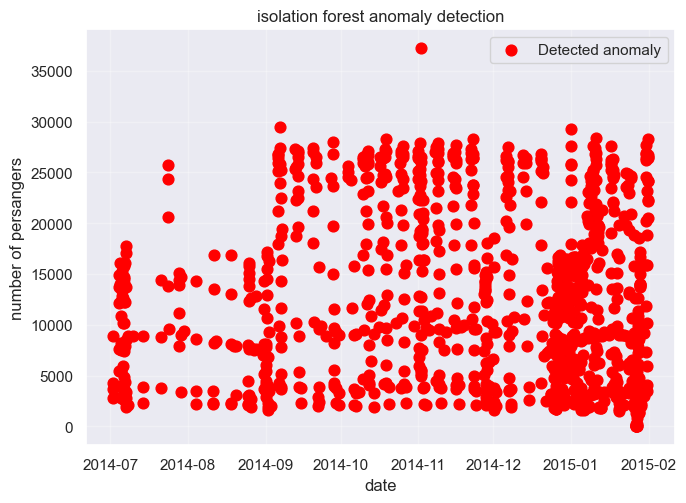

In [1321]:
anomalies= hourly[hourly['anomaly']== 'Anomaly']
plt.figure(figsize=(7.6,5.4))
plt.scatter(anomalies.index, anomalies['value'], color='red',s=60,
            label= 'Detected anomaly',zorder=5, marker='o' )


plt.title('isolation forest anomaly detection')
plt.legend()
plt.xlabel('date')
plt.ylabel('number of persangers')
plt.grid(True,alpha=0.3)
plt.show()

In [1322]:
daily= feature_engineering(daily,'daily')

In [1323]:
daily.dropna(inplace=True)

In [1324]:
w= daily.copy()

In [1325]:
scale= StandardScaler()

In [1326]:
w= scale.fit_transform(w)

In [1327]:
daily['anomaly']=model.predict(w)

In [1328]:
w_pca= pca.transform(w)

In [1329]:
daily['score']= model.decision_function(w)

In [1330]:
daily['x'], daily['y']= w_pca[:,0], w_pca[:,1]

In [1331]:
daily['anomaly']= daily['anomaly'].apply(lambda x : 'Anomaly' if x == -1 else 'Normal')

In [1332]:
daily= daily[['value','day','month','year','anomaly','score','x','y']]

In [1333]:
daily.head()

,value,day,month,year,anomaly,score,x,y
timestamp,,,,,,,,
2014-07-31,15845.062500,31,7,2014,Normal,0.025265,-0.731327,-1.648915
2014-08-01,16024.166667,1,8,2014,Normal,0.031166,0.006905,-1.510294
2014-08-02,16283.666667,2,8,2014,Normal,0.023423,0.244527,-1.592248
2014-08-03,14571.854167,3,8,2014,Normal,0.011956,-0.515086,-1.483773
2014-08-04,13796.145833,4,8,2014,Normal,0.003694,-1.114470,-1.659658


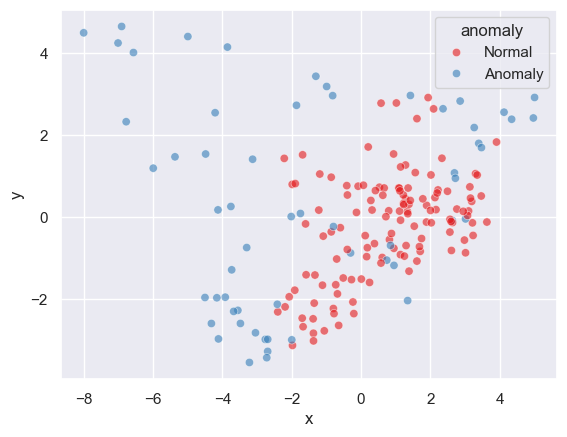

In [1334]:
sns.scatterplot(data=daily, x='x', y='y', hue='anomaly', alpha=0.6)

plt.show()

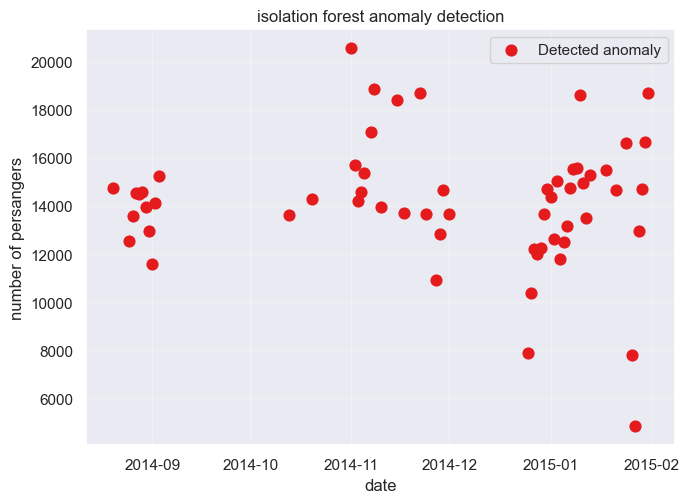

In [1335]:
anomalies= daily[daily['anomaly']== 'Anomaly']
plt.figure(figsize=(7.6,5.4))
plt.scatter(anomalies.index, anomalies['value'],s=60,
            label= 'Detected anomaly',zorder=5, marker='o' )


plt.title('isolation forest anomaly detection')
plt.legend()
plt.xlabel('date')
plt.ylabel('number of persangers')
plt.grid(True,alpha=0.3)
plt.show()

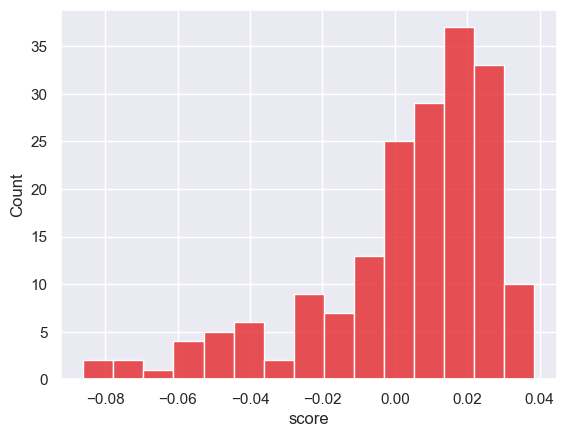

In [1336]:
sns.histplot(data=daily, x='score')

plt.show()